In [1]:
# ============================================================
#  环境配置
# ============================================================

# ── Colab 环境（取消注释后运行） ──
# !pip install torch==2.5.1 torchvision==0.20.1 -q
# !pip install matplotlib==3.9.4 numpy==1.26.4 -q
!pip install captum==0.8.0 networkx==3.4.2 -q
!pip install torch torchvision matplotlib numpy -U -q
# ── 本地 Jupyter 环境 ──
# import subprocess, sys
# def _install(pkg):
#     subprocess.check_call([sys.executable, "-m", "pip", "install", pkg, "-q"])

# _install("torch==2.5.1")
# _install("matplotlib==3.9.4")
# _install("numpy==1.26.4")
# _install("captum==0.8.0")       # PyTorch 模型可解释性库
# _install("networkx==3.4.2")     # 图数据处理

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.0/61.0 kB 6.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 75.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.7/1.7 MB 71.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.0/18.0 MB 97.6 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
jaxlib 0.7.2 requires numpy>=2.0, but you have numpy 1.26.4 which is incompatible.
xarray-einstats 0.10.0 requires numpy>=2.0, but you have numpy 1.26.4 which is incompatible.
opencv-python 4.13.0.92 requires numpy>=2; python_version >= "3.9", but you have numpy 1.26.4 which is incompatible.
rasterio 1.5.0 requires numpy>=2, but you have numpy 1.26.4 which is incompatible.
jax 0.7.2 requires numpy>=2.0, but you have numpy 1.26.4 which is incompatible.
opencv-contrib-python 4.13.0.92 requires numpy>=2; pytho

In [2]:
import math, os
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, TensorDataset
import matplotlib.pyplot as plt
import numpy as np
import networkx as nx
from captum.attr import Saliency, IntegratedGradients
from captum.attr import visualization as viz

torch.manual_seed(42)
np.random.seed(42)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')

Using device: cuda


# 用 AI 引导人类直觉推动数学发展 — 代码实战

基于 Nature 论文 *Advancing Mathematics by Guiding Human Intuition with AI* (Davies et al., 2021)

本论文提出了一种将机器学习作为辅助工具的协作框架，帮助数学家发现猜想和定理，并在**纽结理论**和**表示论**中取得了突破性成果。

## 核心框架

```
假设关系存在 → 生成数据对 (X, Y) → 训练监督模型 → 归因分析 → 提出猜想 → 证明定理
```

本 Notebook 包含两个实验，还原论文的核心方法论：

| | 实验 1 — 纽结不变量预测 | 实验 2 — 图结构性质预测 |
|---|---|---|
| 数据 | 合成纽结不变量（30维几何特征 → 代数量） | 合成图数据（图统计特征 → 图性质） |
| 模型 | 全连接 MLP | 全连接 MLP |
| 关键步骤 | 梯度显著性分析（Saliency） | 积分梯度（Integrated Gradients） |
| 目标 | 发现哪些几何量与代数量相关 | 发现哪些图特征对预测最重要 |

## 1. 核心框架说明

论文的核心思想分三步：

### 第一步：监督学习发现关系
训练模型预测一个数学对象（如代数不变量）与另一个数学对象（如几何不变量）之间的关系。若模型预测准确率远高于随机猜测，则暗示两者存在深刻联系。

### 第二步：归因技术理解模式
采用**梯度显著性分析**（Gradient Saliency）等归因技术，揭示模型在预测时关注了输入的哪些部分。

归因分数计算：
$$\text{Attribution}(x_i) = \left|\frac{\partial f(x)}{\partial x_i}\right|$$

对所有样本取平均后归一化，得到每个特征的重要性排名。

### 第三步：引导直觉提出猜想
基于归因分析发现的模式，数学家有针对性地提出猜想并尝试证明。

## 2. 实验 1：纽结不变量预测

### 背景
数学中的"纽结"是三维空间中不自我相交的闭合环。数学家定义了许多**不变量**来描述纽结，分为**几何不变量**和**代数不变量**两类。核心问题：这些来自不同领域的不变量之间是否存在未知联系？

### 实验设置
- **输入 (X)**：30 个几何不变量（合成数据，模拟体积、Chern-Simons 不变量等）
- **输出 (Y)**：1 个代数不变量（模拟 Signature）
- **隐含关系**：我们设计数据时，让输出 Y 仅依赖于输入中的 3 个特征（模拟论文发现），看模型和归因分析能否自动发现

### 数据生成
$$Y = \sin(X_5) + 0.5 \cdot X_{12}^2 + \text{sign}(X_{23}) + \epsilon$$

其中 $X_5, X_{12}, X_{23}$ 是真正重要的特征，其余 27 个是噪声。

In [3]:
# ── 合成纽结不变量数据 ──
N_SAMPLES = 5000
N_FEATURES = 30
TRUE_FEATURES = [5, 12, 23]  # 真正重要的特征索引

np.random.seed(42)
X_knot = np.random.randn(N_SAMPLES, N_FEATURES).astype(np.float32)

# 构造隐含关系: Y 仅依赖 3 个特征
Y_knot = (np.sin(X_knot[:, 5]) +
          0.5 * X_knot[:, 12]**2 +
          np.sign(X_knot[:, 23]) +
          0.1 * np.random.randn(N_SAMPLES)).astype(np.float32)

# 转为 PyTorch 张量
X_tensor = torch.from_numpy(X_knot)
Y_tensor = torch.from_numpy(Y_knot).unsqueeze(1)  # (N, 1)

# 划分训练/测试
train_X, test_X = X_tensor[:4000], X_tensor[4000:]
train_Y, test_Y = Y_tensor[:4000], Y_tensor[4000:]
train_ds = TensorDataset(train_X, train_Y)
test_ds = TensorDataset(test_X, test_Y)

print(f'训练集: {len(train_ds)}, 测试集: {len(test_ds)}')
print(f'输入维度: {N_FEATURES}, 真正重要的特征: {TRUE_FEATURES}')
print(f'Y 范围: [{Y_knot.min():.2f}, {Y_knot.max():.2f}]')

训练集: 4000, 测试集: 1000
输入维度: 30, 真正重要的特征: [5, 12, 23]
Y 范围: [-2.24, 7.56]


In [4]:
# ── 超参数 ──
HIDDEN_DIM = 128
NUM_EPOCHS = 100
LR = 1e-3
BATCH_SIZE = 128

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True)
test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE)

### 2.1 模型：全连接 MLP

论文使用全连接网络作为"黑盒"预测器。若模型能准确预测，说明输入和输出之间存在可学习的映射关系。

模型架构: 30 → 128 → 128 → 128 → 1 (回归任务)

In [5]:
class MathMLP(nn.Module):
    """全连接 MLP: 用于发现数学量之间的映射关系.
    (B, 30) → hidden layers → (B, 1)
    """
    def __init__(self, input_dim=30, hidden_dim=128, output_dim=1):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, output_dim),
        )

    def forward(self, x):
        return self.net(x)  # (B, 1)

model_knot = MathMLP(N_FEATURES, HIDDEN_DIM, 1).to(device)
print(f'Model params: {sum(p.numel() for p in model_knot.parameters()):,}')

Model params: 37,121


Epoch [20/100]  Train MSE: 0.0423  Test MSE: 0.2503
Epoch [40/100]  Train MSE: 0.0080  Test MSE: 0.2224
Epoch [60/100]  Train MSE: 0.0027  Test MSE: 0.2206
Epoch [80/100]  Train MSE: 0.0056  Test MSE: 0.2300
Epoch [100/100]  Train MSE: 0.0041  Test MSE: 0.2159


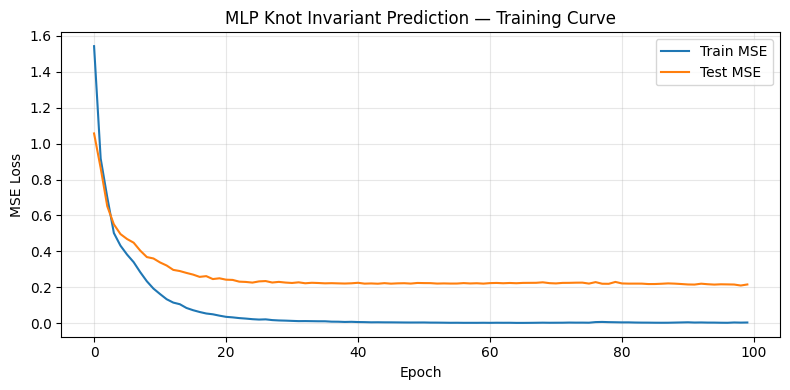

Test R² Score: 0.8927
模型预测准确率远高于随机猜测 → 暗示输入输出之间存在可学习的映射


In [6]:
# ── 训练 ──
optimizer = torch.optim.Adam(model_knot.parameters(), lr=LR)
criterion = nn.MSELoss()

train_losses, test_losses = [], []
for epoch in range(NUM_EPOCHS):
    model_knot.train()
    epoch_loss = 0
    for x, y in train_loader:
        x, y = x.to(device), y.to(device)
        pred = model_knot(x)
        loss = criterion(pred, y)
        optimizer.zero_grad(); loss.backward(); optimizer.step()
        epoch_loss += loss.item()
    train_losses.append(epoch_loss / len(train_loader))

    # 测试损失
    model_knot.eval()
    with torch.no_grad():
        test_preds = model_knot(test_X.to(device))
        test_loss = criterion(test_preds, test_Y.to(device)).item()
    test_losses.append(test_loss)

    if (epoch + 1) % 20 == 0:
        print(f'Epoch [{epoch+1}/{NUM_EPOCHS}]  Train MSE: {train_losses[-1]:.4f}  Test MSE: {test_loss:.4f}')

plt.figure(figsize=(8, 4))
plt.plot(train_losses, label='Train MSE')
plt.plot(test_losses, label='Test MSE')
plt.xlabel('Epoch'); plt.ylabel('MSE Loss')
plt.title('MLP Knot Invariant Prediction — Training Curve')
plt.legend(); plt.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

# R² score
model_knot.eval()
with torch.no_grad():
    preds = model_knot(test_X.to(device)).cpu().numpy().flatten()
    targets = test_Y.numpy().flatten()
    ss_res = np.sum((targets - preds) ** 2)
    ss_tot = np.sum((targets - targets.mean()) ** 2)
    r2 = 1 - ss_res / ss_tot
    print(f'Test R² Score: {r2:.4f}')
    print(f'模型预测准确率远高于随机猜测 → 暗示输入输出之间存在可学习的映射')

### 2.2 归因分析：梯度显著性 (Gradient Saliency)

模型能够准确预测 → 说明关系存在。但模型是黑盒，我们需要**归因技术**找出哪些输入特征最重要。

**梯度显著性（Saliency）**：
$$\text{Saliency}(x_i) = \left|\frac{\partial f(x)}{\partial x_i}\right|$$

对所有测试样本的归因分数取平均值，得到每个特征的全局重要性。

**积分梯度（Integrated Gradients）**：
$$\text{IG}(x_i) = (x_i - x'_i) \times \int_0^1 \frac{\partial f(x' + \alpha(x - x'))}{\partial x_i} d\alpha$$

积分梯度满足**完整性公理**：所有特征归因之和等于模型输出的差值。

In [7]:
# ── 梯度显著性分析 ──
model_knot.eval()
saliency = Saliency(model_knot)
ig = IntegratedGradients(model_knot)

# 对测试集计算归因
test_input = test_X.to(device)
test_input.requires_grad = True

# Saliency 归因: 取绝对梯度的平均
saliency_attr = saliency.attribute(test_input, target=None,
                                    abs=True)  # (1000, 30)
mean_saliency = saliency_attr.mean(dim=0).detach().cpu().numpy()  # (30,)

# Integrated Gradients 归因
ig_attr = ig.attribute(test_input, target=None,
                       n_steps=50)  # (1000, 30)
mean_ig = ig_attr.abs().mean(dim=0).detach().cpu().numpy()  # (30,)

# 归一化
mean_saliency /= mean_saliency.max()
mean_ig /= mean_ig.max()

print('Top 5 features by Saliency:')
top_sal = np.argsort(mean_saliency)[::-1][:5]
for rank, idx in enumerate(top_sal):
    marker = ' ★ 真实重要特征' if idx in TRUE_FEATURES else ''
    print(f'  Rank {rank+1}: Feature {idx} (score={mean_saliency[idx]:.4f}){marker}')

print('\nTop 5 features by Integrated Gradients:')
top_ig = np.argsort(mean_ig)[::-1][:5]
for rank, idx in enumerate(top_ig):
    marker = ' ★ 真实重要特征' if idx in TRUE_FEATURES else ''
    print(f'  Rank {rank+1}: Feature {idx} (score={mean_ig[idx]:.4f}){marker}')

Top 5 features by Saliency:
  Rank 1: Feature 23 (score=1.0000) ★ 真实重要特征
  Rank 2: Feature 12 (score=0.8081) ★ 真实重要特征
  Rank 3: Feature 5 (score=0.6476) ★ 真实重要特征
  Rank 4: Feature 22 (score=0.0973)
  Rank 5: Feature 18 (score=0.0968)

Top 5 features by Integrated Gradients:
  Rank 1: Feature 23 (score=1.0000) ★ 真实重要特征
  Rank 2: Feature 12 (score=0.7250) ★ 真实重要特征
  Rank 3: Feature 5 (score=0.6590) ★ 真实重要特征
  Rank 4: Feature 3 (score=0.1157)
  Rank 5: Feature 20 (score=0.0917)


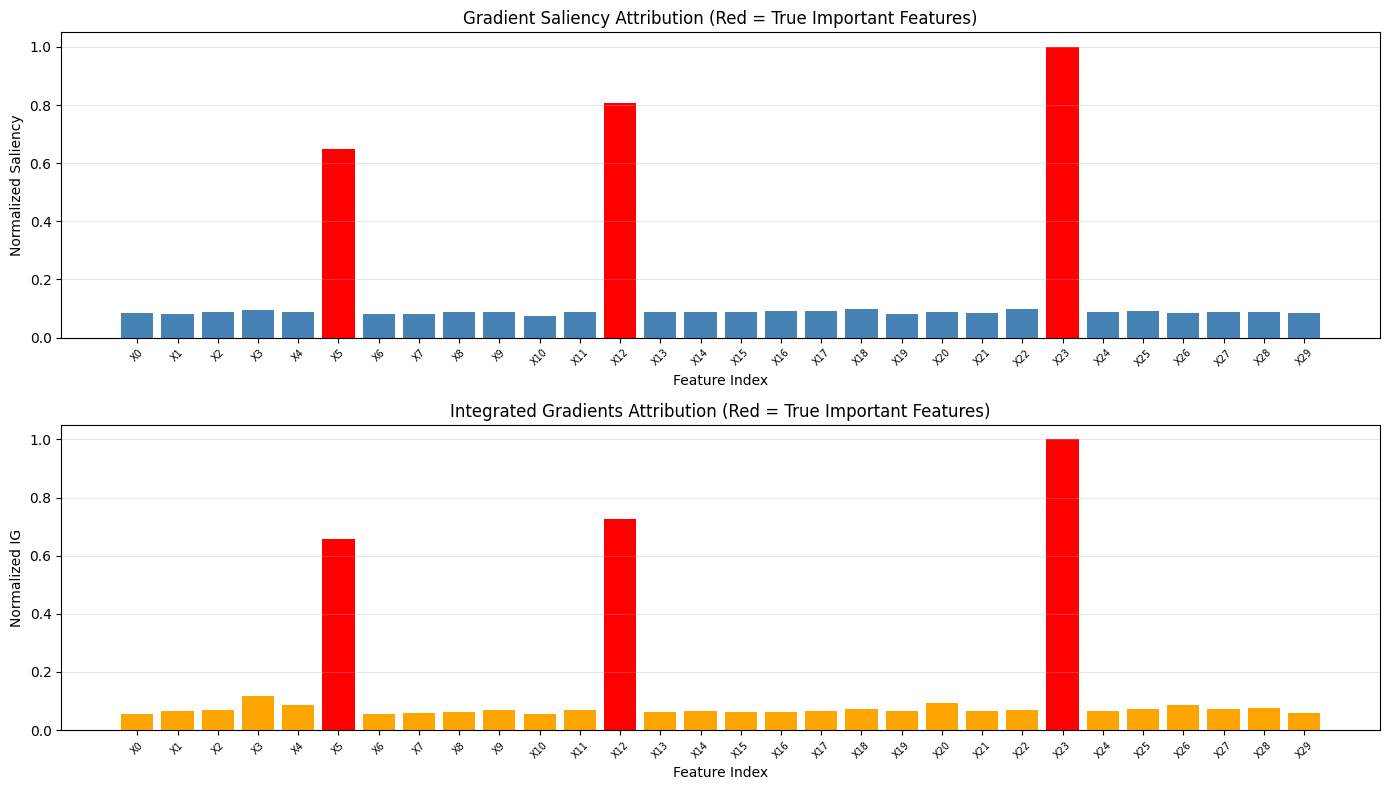


归因分析发现的真实重要特征: {12, 5, 23}
真实重要特征: {12, 5, 23}
✓ 归因分析成功识别了所有真实重要特征！


In [8]:
# ── 归因分数可视化 ──
fig, axes = plt.subplots(2, 1, figsize=(14, 8))

feature_names = [f'X{i}' for i in range(N_FEATURES)]
colors_sal = ['red' if i in TRUE_FEATURES else 'steelblue' for i in range(N_FEATURES)]
colors_ig = ['red' if i in TRUE_FEATURES else 'orange' for i in range(N_FEATURES)]

axes[0].bar(range(N_FEATURES), mean_saliency, color=colors_sal)
axes[0].set_xlabel('Feature Index'); axes[0].set_ylabel('Normalized Saliency')
axes[0].set_title('Gradient Saliency Attribution (Red = True Important Features)')
axes[0].set_xticks(range(N_FEATURES))
axes[0].set_xticklabels(feature_names, fontsize=7, rotation=45)
axes[0].grid(axis='y', alpha=0.3)

axes[1].bar(range(N_FEATURES), mean_ig, color=colors_ig)
axes[1].set_xlabel('Feature Index'); axes[1].set_ylabel('Normalized IG')
axes[1].set_title('Integrated Gradients Attribution (Red = True Important Features)')
axes[1].set_xticks(range(N_FEATURES))
axes[1].set_xticklabels(feature_names, fontsize=7, rotation=45)
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout(); plt.show()

# 验证: 真实重要特征是否被正确识别
discovered = set(top_sal[:3]) & set(TRUE_FEATURES)
print(f'\n归因分析发现的真实重要特征: {discovered}')
print(f'真实重要特征: {set(TRUE_FEATURES)}')
if discovered == set(TRUE_FEATURES):
    print('✓ 归因分析成功识别了所有真实重要特征！')
else:
    print(f'部分识别: {len(discovered)}/{len(TRUE_FEATURES)} 个特征被正确发现')

### 2.3 特征与目标的关系可视化

归因分析发现了重要特征后，数学家可以进一步分析这些特征与目标之间的具体关系，为提出精确的数学猜想提供线索。

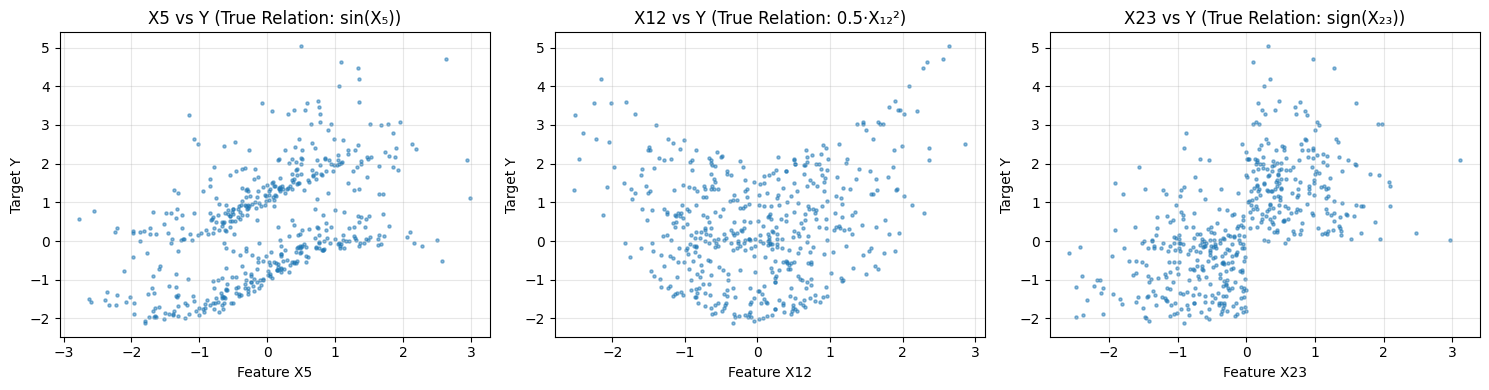

从散点图可以直观看到各特征与目标的非线性关系，引导数学家提出精确猜想


In [9]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, fidx, formula in zip(axes, TRUE_FEATURES,
                              ['sin(X₅)', '0.5·X₁₂²', 'sign(X₂₃)']):
    ax.scatter(X_knot[:500, fidx], Y_knot[:500], s=5, alpha=0.5)
    ax.set_xlabel(f'Feature X{fidx}'); ax.set_ylabel('Target Y')
    ax.set_title(f'X{fidx} vs Y (True Relation: {formula})')
    ax.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()
print('从散点图可以直观看到各特征与目标的非线性关系，引导数学家提出精确猜想')

## 3. 实验 2：图结构性质预测（表示论模拟）

### 背景
论文的第二个实验涉及**表示论**：训练 GNN 从对称群的布吕阿区间图结构预测 Kazhdan-Lusztig 多项式。

### 简化模拟
我们用合成图数据模拟：
- **输入**：从随机图中提取 10 个统计特征（节点数、边数、密度、聚类系数、连通分量数等）
- **输出**：基于其中 3 个特征的组合（模拟 KL 多项式值）
- **目标**：训练 MLP 预测，然后通过归因发现哪些图特征最重要

In [10]:
# ── 合成图数据 ──
def extract_graph_features(G):
    """从 NetworkX 图中提取 10 个统计特征."""
    n = G.number_of_nodes()
    m = G.number_of_edges()
    density = nx.density(G)
    avg_clustering = nx.average_clustering(G)
    n_components = nx.number_connected_components(G)
    degrees = [d for _, d in G.degree()]
    avg_degree = np.mean(degrees) if degrees else 0
    max_degree = max(degrees) if degrees else 0
    degree_std = np.std(degrees) if degrees else 0
    # 最大连通分量的直径（近似）
    if n_components > 0:
        largest_cc = max(nx.connected_components(G), key=len)
        subG = G.subgraph(largest_cc)
        if len(largest_cc) > 1:
            diameter = nx.diameter(subG)
        else:
            diameter = 0
    else:
        diameter = 0
    transitivity = nx.transitivity(G)
    return np.array([n, m, density, avg_clustering, n_components,
                     avg_degree, max_degree, degree_std, diameter,
                     transitivity], dtype=np.float32)

N_GRAPHS = 2000
GRAPH_FEATURES = 10
GRAPH_TRUE_FEATURES = [2, 3, 9]  # density, avg_clustering, transitivity

np.random.seed(42)
X_graph_list, Y_graph_list = [], []
for i in range(N_GRAPHS):
    n_nodes = np.random.randint(8, 25)
    p = np.random.uniform(0.1, 0.6)
    G = nx.erdos_renyi_graph(n_nodes, p, seed=i)
    feats = extract_graph_features(G)
    X_graph_list.append(feats)
    # 隐含关系: Y 依赖 density, avg_clustering, transitivity
    y = 2.0 * feats[2] + 1.5 * np.tanh(feats[3]) + feats[9] + 0.1 * np.random.randn()
    Y_graph_list.append(y)

X_graph = torch.tensor(np.array(X_graph_list))  # (2000, 10)
Y_graph = torch.tensor(np.array(Y_graph_list)).unsqueeze(1).float()  # (2000, 1)

# 先划分，再用训练集统计量标准化（避免数据泄漏）
X_train_raw, X_test_raw = X_graph[:1600], X_graph[1600:]
X_mean, X_std = X_train_raw.mean(0), X_train_raw.std(0)
X_std[X_std == 0] = 1
g_train_X = (X_train_raw - X_mean) / X_std
g_test_X = (X_test_raw - X_mean) / X_std  # 用训练集统计量归一化测试集

g_train_Y, g_test_Y = Y_graph[:1600], Y_graph[1600:]
g_train_ds = TensorDataset(g_train_X, g_train_Y)
g_train_loader = DataLoader(g_train_ds, batch_size=64, shuffle=True)

graph_feature_names = ['n_nodes', 'n_edges', 'density', 'avg_clust',
                       'n_comp', 'avg_deg', 'max_deg', 'deg_std',
                       'diameter', 'transitivity']
print(f'图数据: {N_GRAPHS} graphs, {GRAPH_FEATURES} features')
print(f'真实重要特征: {[graph_feature_names[i] for i in GRAPH_TRUE_FEATURES]}')

图数据: 2000 graphs, 10 features
真实重要特征: ['density', 'avg_clust', 'transitivity']


In [11]:
model_graph = MathMLP(GRAPH_FEATURES, 64, 1).to(device)
optimizer_g = torch.optim.Adam(model_graph.parameters(), lr=1e-3)

losses_g = []
for epoch in range(80):
    model_graph.train()
    el = 0
    for x, y in g_train_loader:
        x, y = x.to(device), y.to(device)
        loss = F.mse_loss(model_graph(x), y)
        optimizer_g.zero_grad(); loss.backward(); optimizer_g.step()
        el += loss.item()
    losses_g.append(el / len(g_train_loader))
    if (epoch + 1) % 20 == 0:
        model_graph.eval()
        with torch.no_grad():
            test_pred = model_graph(g_test_X.to(device))
            test_mse = F.mse_loss(test_pred, g_test_Y.to(device)).item()
        print(f'Epoch [{epoch+1}/80]  Train: {losses_g[-1]:.4f}  Test: {test_mse:.4f}')

# R² on test
model_graph.eval()
with torch.no_grad():
    pred_g = model_graph(g_test_X.to(device)).cpu().numpy().flatten()
    tgt_g = g_test_Y.numpy().flatten()
    r2_g = 1 - np.sum((tgt_g - pred_g)**2) / np.sum((tgt_g - tgt_g.mean())**2)
    print(f'Graph Test R²: {r2_g:.4f}')

Epoch [20/80]  Train: 0.0114  Test: 0.0120
Epoch [40/80]  Train: 0.0105  Test: 0.0113
Epoch [60/80]  Train: 0.0099  Test: 0.0110
Epoch [80/80]  Train: 0.0103  Test: 0.0113
Graph Test R²: 0.9797


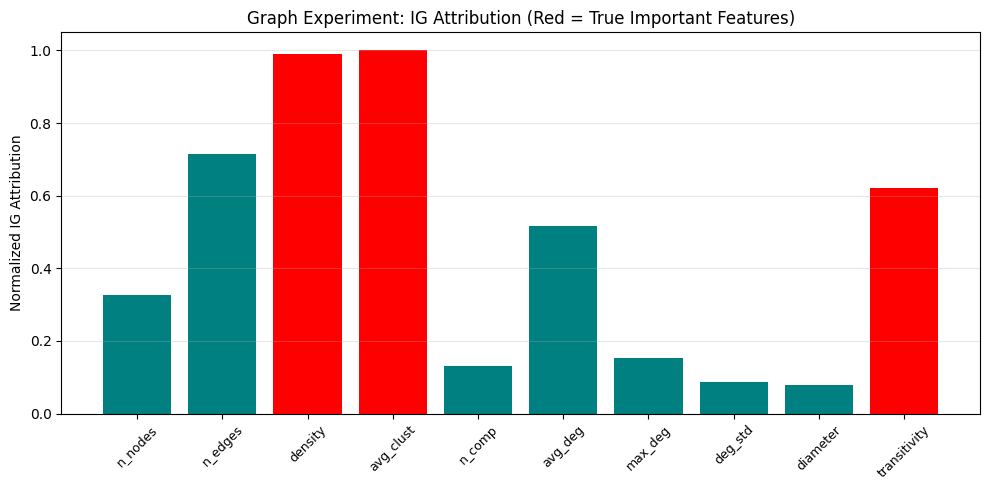


Top 3 features:
  1. avg_clust (score=1.0000) ★
  2. density (score=0.9899) ★
  3. n_edges (score=0.7144)


In [12]:
# ── 图实验归因分析 ──
model_graph.eval()
ig_graph = IntegratedGradients(model_graph)

g_input = g_test_X.to(device)
g_input.requires_grad = True

ig_attr_g = ig_graph.attribute(g_input, target=None, n_steps=50)
mean_ig_g = ig_attr_g.abs().mean(dim=0).detach().cpu().numpy()
mean_ig_g /= mean_ig_g.max()

fig, ax = plt.subplots(figsize=(10, 5))
colors_g = ['red' if i in GRAPH_TRUE_FEATURES else 'teal' for i in range(GRAPH_FEATURES)]
ax.bar(range(GRAPH_FEATURES), mean_ig_g, color=colors_g)
ax.set_xticks(range(GRAPH_FEATURES))
ax.set_xticklabels(graph_feature_names, rotation=45, fontsize=9)
ax.set_ylabel('Normalized IG Attribution')
ax.set_title('Graph Experiment: IG Attribution (Red = True Important Features)')
ax.grid(axis='y', alpha=0.3)
plt.tight_layout(); plt.show()

print('\nTop 3 features:')
top3 = np.argsort(mean_ig_g)[::-1][:3]
for r, idx in enumerate(top3):
    m = ' ★' if idx in GRAPH_TRUE_FEATURES else ''
    print(f'  {r+1}. {graph_feature_names[idx]} (score={mean_ig_g[idx]:.4f}){m}')

## 4. 框架总结

### 完整流程回顾

| 步骤 | 数学家 | AI (机器学习) |
|------|--------|------------|
| 1. 提出假设 | 猜测几何量与代数量之间可能存在映射 | — |
| 2. 生成数据 | — | 收集 (X, Y) 数据对 |
| 3. 监督学习 | — | 训练 MLP/GNN，验证关系是否可学习 |
| 4. 归因分析 | — | Saliency / IG 找出关键特征 |
| 5. 提出猜想 | 根据归因结果，聚焦关键特征，提出精确猜想 | — |
| 6. 证明定理 | 传统数学证明 | — |

### 关键启示

1. **AI 不是替代数学家，而是增强其直觉**：AI 处理高维数据中的模式发现，数学家负责理解和证明
2. **归因技术是桥梁**：将黑盒模型的"知识"转化为人类可理解的线索
3. **适用范围**：任何涉及"从对象 A 的属性预测对象 B 的属性"的数学问题

## 附录：面试拓展

### 高频面试题

**Q1: 这篇论文的核心贡献是什么？**

- 首次在顶级数学期刊（Nature）展示 ML 可以作为数学发现的辅助工具
- 提出了系统化的"假设→数据→模型→归因→猜想→证明"框架
- 在纽结理论中发现了 3 个几何不变量与 Signature 的新关系
- 在表示论中为 Kazhdan-Lusztig 猜想提供了新证据

**Q2: 为什么用 MLP 而不是更复杂的模型？**

- 目标不是追求最高精度，而是验证"关系是否存在"
- 简单模型更容易做归因分析（梯度更稳定）
- 如果简单模型就能预测准确，说明关系确实存在且可能较简洁

**Q3: 梯度显著性（Saliency）和积分梯度（Integrated Gradients）的区别？**

| | Saliency | Integrated Gradients |
|---|---|---|
| 计算方式 | 单点梯度的绝对值 | 从基线到输入的路径积分 |
| 公理满足 | 不满足完整性公理 | 满足完整性公理 |
| 计算成本 | 低（一次反向传播） | 高（多次反向传播） |
| 稳定性 | 可能受局部噪声影响 | 更稳定、更全局 |

**Q4: 这种方法的局限性是什么？**

- 需要数学家先提出合理的假设（AI 无法无中生有）
- 归因分析只能找到"重要特征"，不能直接给出数学公式
- 依赖数据质量和覆盖范围
- 从归因结果到数学定理之间仍需人类的创造性跳跃

**Q5: AI for Science 的其他代表性工作？**

| 工作 | 领域 | 方法 |
|------|------|------|
| AlphaFold2 | 蛋白质结构预测 | Transformer + Evoformer |
| GNoME | 材料发现 | GNN + 主动学习 |
| 本文 (Davies et al.) | 纯数学 | MLP/GNN + 归因分析 |
| AlphaGeometry | 几何证明 | 符号推理 + 语言模型 |

**Q6: 为什么论文在表示论实验中使用 GNN 而非 MLP？**

- 表示论的数据是**图结构**（布吕阿区间图），有节点和边
- GNN 天然适合处理图结构数据，能捕获拓扑信息
- MLP 需要手动提取图特征（如我们实验中所做），可能丢失结构信息

### 进阶探索方向

- **更强的归因方法**：SHAP、注意力权重分析、概念激活向量 (TCAV)
- **符号回归**：不仅找到重要特征，还能直接恢复数学公式（如 PySR）
- **主动学习**：让 AI 主动选择最有信息量的数据点进行实验
- **LLM for Math**：大语言模型在数学推理中的应用（如 Lean 定理证明辅助）